## A. Image Noise

### Salt and Pepper Noise

Below is the function to add salt and pepper noise on the image kodim21.png converted into grayscale

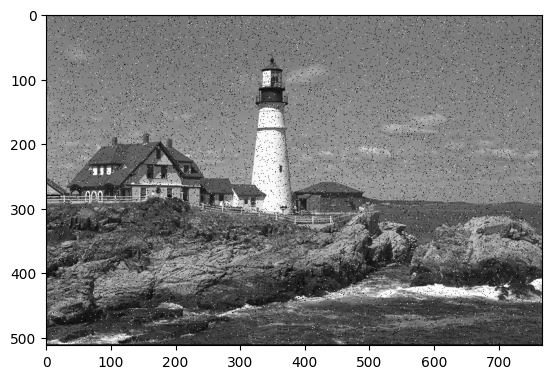

In [65]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Adding salt and pepper noise using numpy (white and black pixels between 300 and 10000)
def add_salt_pepper_noise(img):

    row , col = img.shape
    
    number_of_white_pixels = np.random.randint(300, 10000)
    for i in range(number_of_white_pixels):
        y_coord=np.random.randint(0, row - 1)             
        x_coord=np.random.randint(0, col - 1)
        img[y_coord][x_coord] = 255

    number_of_black_pixels = np.random.randint(300, 10000)
    for i in range(number_of_black_pixels):
        y_coord=np.random.randint(0, row - 1)             
        x_coord=np.random.randint(0, col - 1)
        img[y_coord][x_coord] = 0

    #plotting the noisy image
    return img

# converting image to grayscale using OpenCV
grayscale_img = cv2.imread('kodim21.png', cv2.IMREAD_GRAYSCALE)

add_salt_pepper_noise(grayscale_img)

plt.imshow(add_salt_pepper_noise(grayscale_img), cmap='gray')



### Gaussian Noise

Below function adds Gaussian noise to given grayscale image by using numpy and plots the resulting image.

Note: Convert image and noise to the same data type and account for values larger than the range of pixel values e.g., 255 after adding noise. Use zero mean and a standard deviation of 0.05 for the gaussian noise.

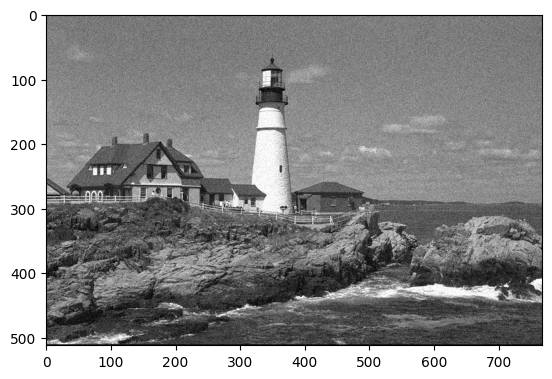

In [66]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def add_gaussian_noise(img):

    normalised_image = img.astype(np.float32)/255.0
    row, col = normalised_image.shape
    mean = 0
    sigma = 0.05

    noise = np.random.normal(loc=mean , scale=sigma , size=(row, col))
    
    # adding gaussian noise
    noisy_image_float = normalised_image + noise

    # accounting for values larger than range of pixel values
    noisy_image_clipped = np.clip(noisy_image_float, 0, 1)

    noisy_image_uint8 = (noisy_image_clipped*255).astype(np.uint8)

    return plt.imshow(noisy_image_uint8, cmap='gray')

# converting image to grayscale using OpenCV
grayscale_img = cv2.imread('kodim21.png', cv2.IMREAD_GRAYSCALE)

add_gaussian_noise(grayscale_img)

## B. Convolution

Implement the convolution algorithm in numpy, with stride 1. Your implementation shall be able to handle kernels with size 3x3 and 5x5, and should not make use of any library calls to perform the actual convolution.

Note: To obtain an output with the same size as the input zero padding is required.

Apply your implemented convolution with the following filters, plot the output and explain which effect each kernel has on the input image.

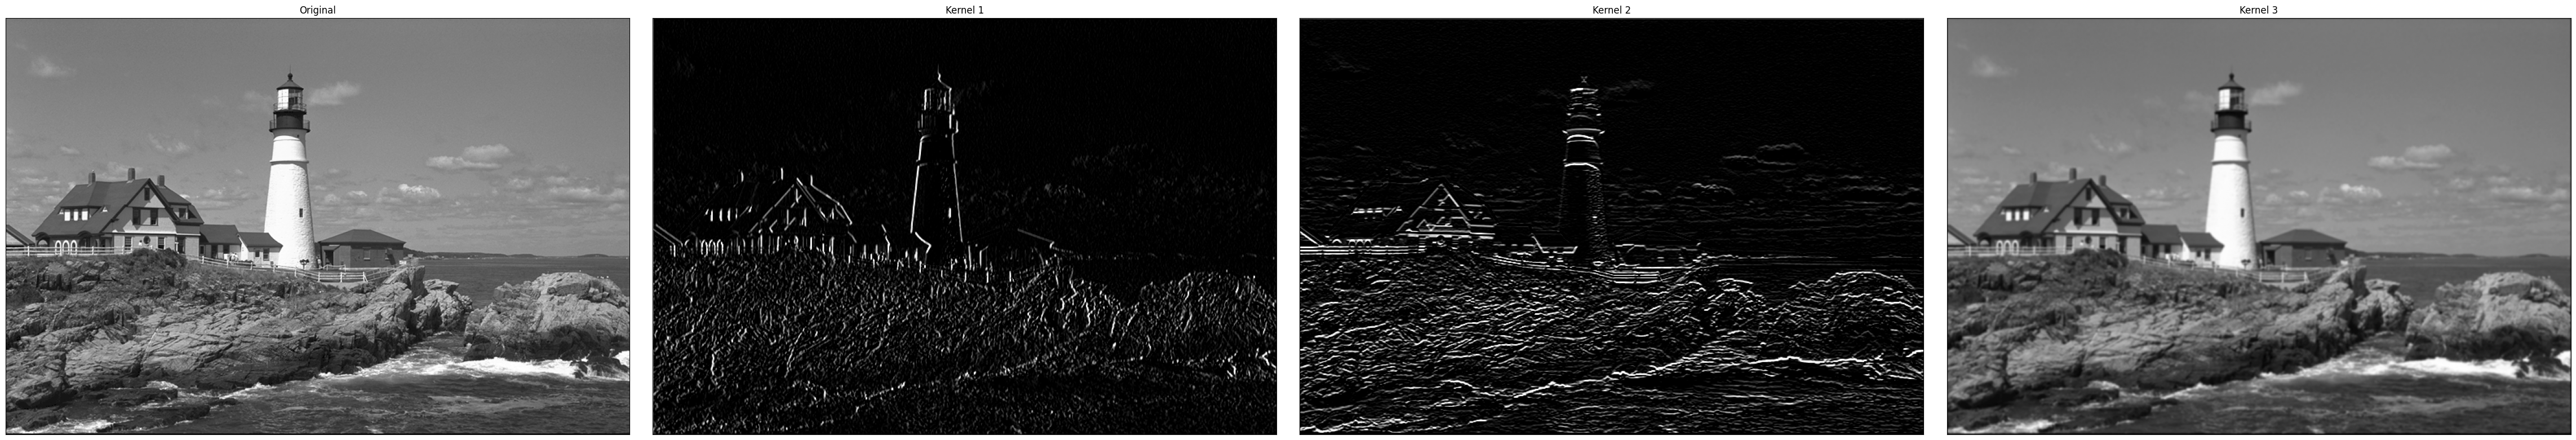

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def convolve2d(image, kernel):

    original_image_float =  image.astype(np.float32)

    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # Calculate padding needed for output size
    pad_h = (kernel_height - 1) // 2
    pad_w = (kernel_width - 1) // 2

    # Add padding to top, bottom, left, right
    padded_image = np.pad(original_image_float, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)

    output_height = image_height
    output_width = image_width
    
    # initialize the output convolved image
    convolved_image = np.zeros((output_height, output_width), dtype=np.float32)

    for i in range(output_height):
        for j in range(output_width):
            region = padded_image[i : i + kernel_height, j : j + kernel_width]
            convolved_image[i, j] = np.sum(region * kernel)
            
    convolved_image_uint8 = np.clip(convolved_image, 0, 255).astype(np.uint8)

    return convolved_image_uint8

kernel1 = np.array([[-1, 0, 1],
                   [-1, 0, 1],
                   [-1, 0, 1]])
    
kernel2 = np.array([[-1, -1, -1],
                  [0, 0, 0],
                  [1, 1, 1]])

kernel3 =  1/256 * np.array([[1, 4, 6, 4, 1],
                    [4, 16, 24, 16, 4],
                    [6, 24, 36, 24, 6],
                    [4, 16, 24, 16, 4],
                    [1, 4, 6, 4, 1]])

grayscale_img = cv2.imread('kodim21.png', cv2.IMREAD_GRAYSCALE)

kernel1_convolution = convolve2d(grayscale_img, kernel1)
kernel2_convolution = convolve2d(grayscale_img, kernel2)
kernel3_convolution = convolve2d(grayscale_img, kernel3)

img_height, img_width = grayscale_img.shape
scale_factor = 0.015
fig_width = (img_width * 4 * scale_factor)
fig_height = (img_height * scale_factor)
plt.figure(figsize=(fig_width, fig_height))

plt.subplot(1, 4, 1)
plt.imshow(grayscale_img, cmap='gray')
plt.title('Original')
plt.xticks([]), plt.yticks([])


plt.subplot(1, 4, 2) 
plt.imshow(kernel1_convolution, cmap='gray')
plt.title('Kernel 1')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 4, 3)
plt.imshow(kernel2_convolution, cmap='gray')
plt.title('Kernel 2')
plt.xticks([]), plt.yticks([])


plt.subplot(1, 4, 4)
plt.imshow(kernel3_convolution, cmap='gray')
plt.title('Kernel 3')
plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()



### Kernel Analysis

Kernel 1 is vertical edge detection;
Kernel 2 is horizontal edge detection;
Kernel 3 is Gaussian filter and is blurring the image;



## C. Filtering

OpenCV filters for averaging, gaussian blur, median and bilateral filtering.

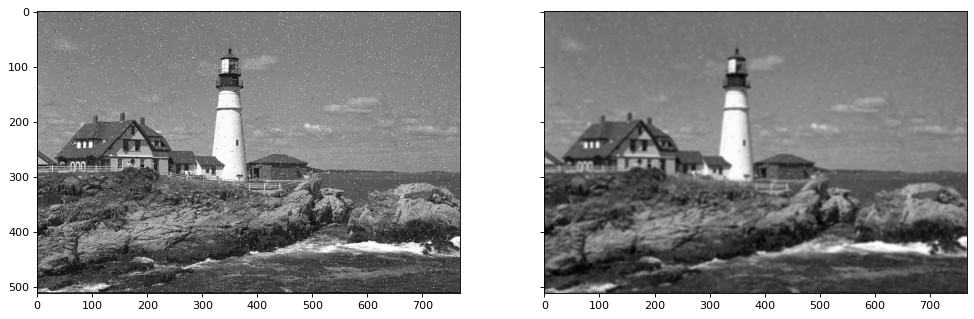

In [68]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

grayscale_img = cv2.imread('kodim21.png', cv2.IMREAD_GRAYSCALE)

noisy_image = add_salt_pepper_noise(grayscale_img)

#Averaging filter
avg_filter_img = cv2.blur(noisy_image,(5,5))

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 7), dpi=80, sharex=True, sharey=True)
ax[0].imshow(noisy_image, cmap='gray')
ax[1].imshow(avg_filter_img, cmap='gray')

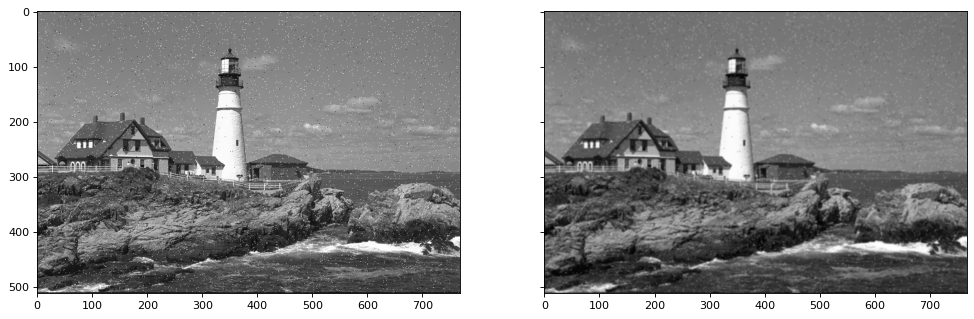

In [69]:
# Guassian blur filter
gaussian_blur = cv2.GaussianBlur(noisy_image,(5,5),0)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 7), dpi=80, sharex=True, sharey=True)
ax[0].imshow(noisy_image, cmap='gray')
ax[1].imshow(gaussian_blur, cmap='gray')

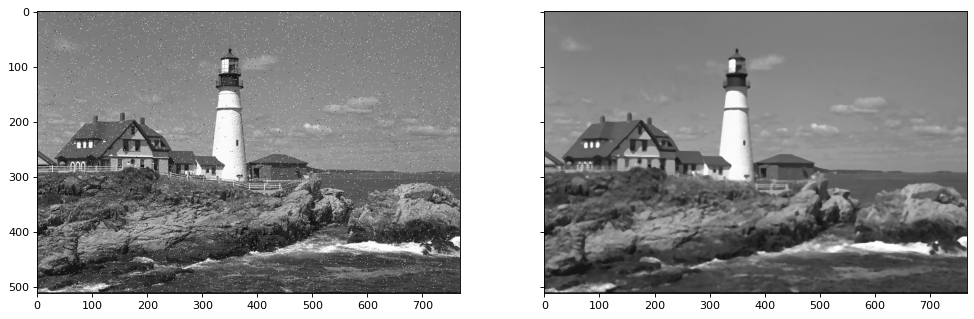

In [70]:
# Median blur filter
median_blurring = cv2.medianBlur(noisy_image,5)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 7), dpi=80, sharex=True, sharey=True)
ax[0].imshow(noisy_image, cmap='gray')
ax[1].imshow(median_blurring, cmap='gray')

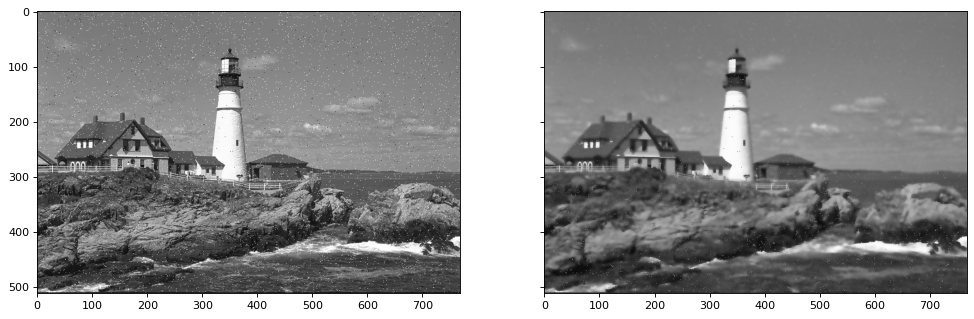

In [71]:
# Bilateral filter
bilateral_filter = cv2.bilateralFilter(noisy_image,9,75,75)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 7), dpi=80, sharex=True, sharey=True)
ax[0].imshow(noisy_image, cmap='gray')
ax[1].imshow(bilateral_filter, cmap='gray')

### The best performing filter here is Median Filter since it's not affected my extreme low and high values unlike the other filters.